$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.12

## 理论

图 4.12 绘制了极大投影设计与最大最小距离拉丁超立方设计（MmLHD），分别在一维、二维、三维、四维投影空间以及完整维度空间内，所有样本点两两最小距离的最小值变化曲线。不难看出，在完整维度空间中，最大最小距离拉丁超立方设计的最小距离更大，这一现象符合理论预期，因为该设计的构造思路本身就是在全维度空间内最大化样本点之间的最小距离。但将样本点投影至二维、三维或四维空间后，极大投影设计的最小距离反而更大。该特性具备实用价值，原因在于开展实验前，我们无法预知哪些维度属于关键维度。极大投影设计在一维投影中的最小距离小于最大最小距离拉丁超立方设计，原因是极大投影设计中有更多样本点靠近区域边界。总体而言，在维度为 2 至 $p-1$ 的投影空间里，极大投影设计的表现通常优于最大最小距离拉丁超立方设计，因此面对各变量重要程度未知的情况，极大投影设计具备更强的稳健性。

## 实践

创建画布宽 10 英寸、高 10 英寸。令 p=5，n=50，定义种子为 1。导入 SFDesign 包，调用 maxproLHD() 函数生成 n 个、p 维的初始极大极小拉丁超立方设计，取其 design 列正是设计点，令其为 D1。调用 maxproLHD() 函数先生成 n 个、p 维的初始极大投影设计，取其 design 列再调用 maxpro.optim() 函数进行极大投影设计优化，取其 design 列正是最终的极大投影设计点，令其为 D2。

导入 gtools 包，定义函数 min_mindist() 计算输入矩阵 M 中每个投影维度中的最小距离的最小值，其中提取 M 的行为 n，列为 p。创建 p 维 0 向量 a，对于 j 从 1:p，从 p 中选择 j 个维度的组合，$C_p^j\times j$ 维的矩阵令其为 comb，提取其行数令其为 k。创建 k 维 0 向量 temp，对于 i 从 1:k，计算 M 的 comb[i,] 列的两两距离，取其最小值令其为 temp[i]。将 temp 的最小值赋值给 a[j]。返回的向量 a 即为矩阵 M 中每个投影维度中的最小距离的最小值。

输入 D1 和 D2，分别计算其在每个投影维度中的最小距离的最小值，令其为 d1 和 d2。绘制 d1 和 d2 的变化曲线，其中类型为 b，点形状为 4 和 1，颜色为 2、4，线型为 2、1，无边框，x 轴范围为 c(1,5)，y 轴范围为 c(0,0.5)，x 轴标签为“投影维度”，y 轴标签为“最小距离的最小值”，点大小、标签大小、坐标轴大小均为 2，线宽为 3。添加图例，其中位置在 (1,0.5)，标签分别为“极大投影设计”和“极大极小拉丁超立方设计”，点形状为 1、4，线型为 1、2，无边框，线宽为 3，颜色为 4、2，标签大小为 2。

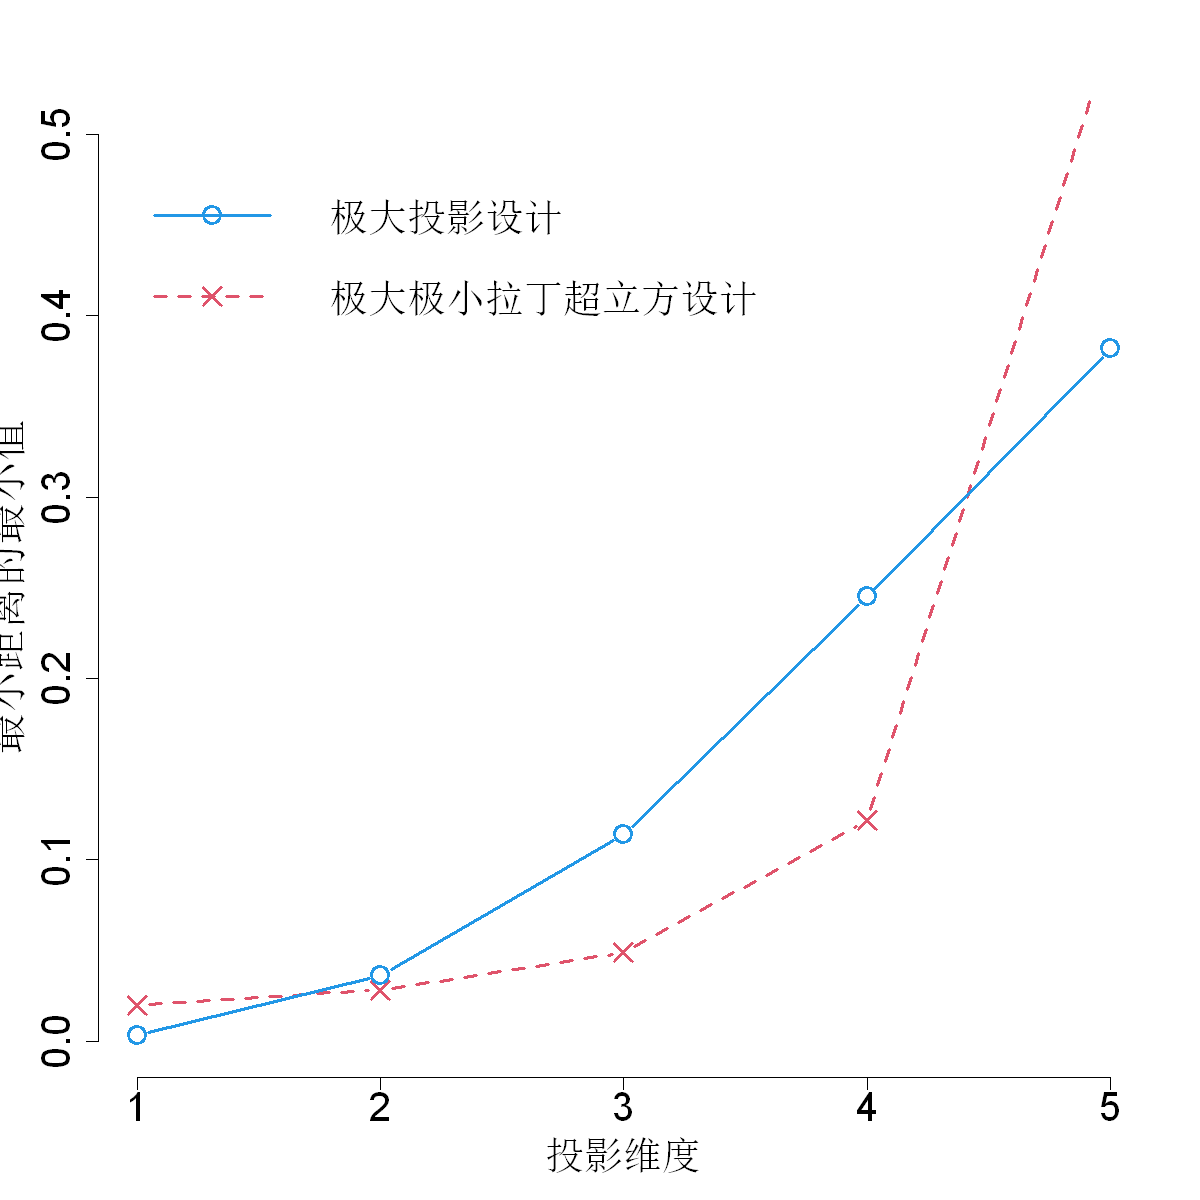

In [2]:
options(repr.plot.width=10,repr.plot.height=10)
p=5;n=50
set.seed(1)
library(SFDesign)
D1=maximinLHD(n,p)$design
D2=maxpro.optim(maxproLHD(n,p)$design)$design

library(gtools)
min_mindist=function(M){
    n=nrow(M)
    p=ncol(M)
    a=rep(0,p)
    for(j in 1:p){
        comb=combinations(p,j) # C_p^jxj
        k=nrow(comb)
        temp=rep(0,k)
        for(i in 1:k)temp[i]=min(dist(M[,comb[i,]]))
        a[j]=min(temp)
    }
    return(a)
}

d1=min_mindist(D1)
d2=min_mindist(D2)
matplot(1:p,cbind(d1,d2),type="b",pch=c(4,1),col=c(2,4),lty=c(2,1),bty="n",xlim=c(1,5),ylim=c(0,0.5),xlab="投影维度",ylab="最小距离的最小值",cex=2,cex.lab=2,cex.axis=2,lwd=3)
legend(1,.5,c("极大投影设计","极大极小拉丁超立方设计"),pch=c(1,4),lty=c(1,2),bty='n',lwd=3,col=c(4,2),cex=2)

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$